**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4029 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 8**
Regresión Lineal

---

*   NOMBRE: Gabriela Anahi Parra -
*   MATRÍCULA: A01753492

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Importar las bibliotecas necesarias
import pandas as pd

In [3]:
ruta_archivo = "/content/drive/MyDrive/Colab Notebooks/Maestria en IA/Ciencia de datos enero 2026/insurance.csv"
insurance_df = pd.read_csv(ruta_archivo)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# **Parte 1**. EDA

Efectúa una exploración inicial de los datos a través de:

1a) Estadísticas descriptivas para todas las variables del dataframe.

In [6]:
# Guardar el resumen básico (media, min, max, )
resumen_num = insurance_df.select_dtypes(include='number').describe()

# Agregar las filas de sesgo (skew) y curtosis (kurt)
resumen_num.loc['skew'] = insurance_df.select_dtypes(include='number').skew()
resumen_num.loc['kurt'] = insurance_df.select_dtypes(include='number').kurt()

resumen_num

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010
skew,0.055673,0.284047,0.938380,1.515880
kurt,-1.245088,-0.050732,0.202454,1.606299


In [7]:
# Resumen estadístico de categoricas
insurance_df.select_dtypes(include='object').describe()
insurance_df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [8]:
# Tablas de frecuencia]
for col in insurance_df.select_dtypes(include='object').columns:
    # Mostramos el nombre de la columna y su Top 10
    display(insurance_df[col].value_counts().head(10).to_frame())

,count
sex,
male,676
female,662


,count
smoker,
no,1064
yes,274


,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


1b) Búsqueda de valores faltantes.

In [9]:
#faltantes
print(f"Faltantes:\n{insurance_df.isnull().sum()}")

Faltantes:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


1c) Histrogramas y boxplots para las variables cuantitativas y diagramas de barras con la frecuencia para las variables categóricas.

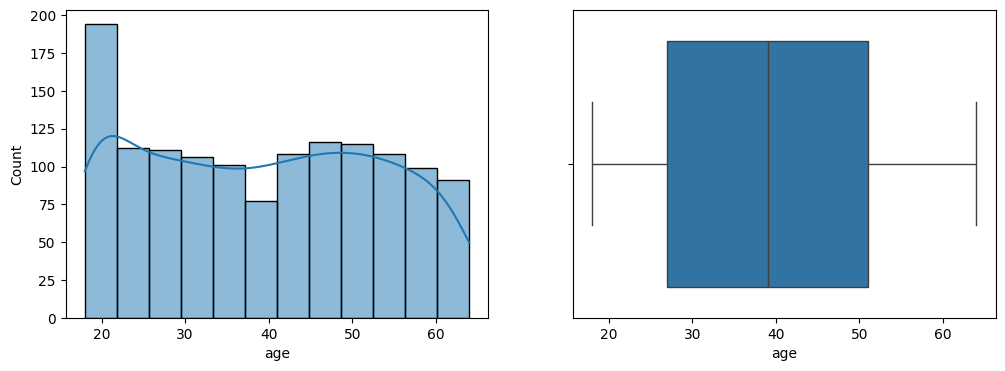

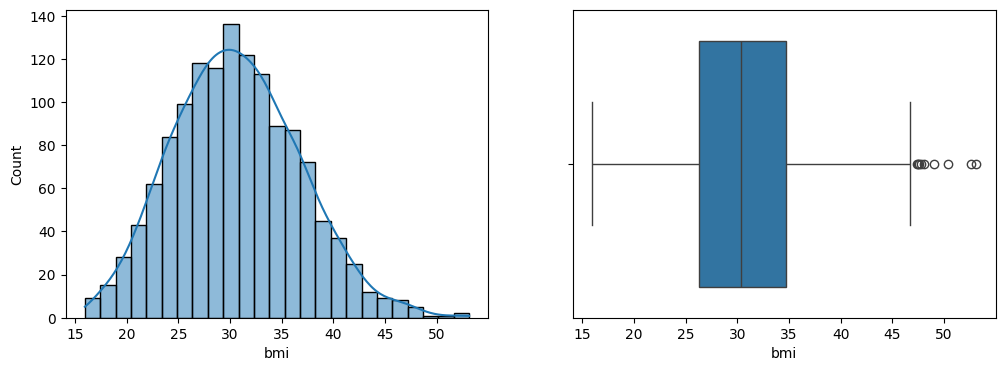

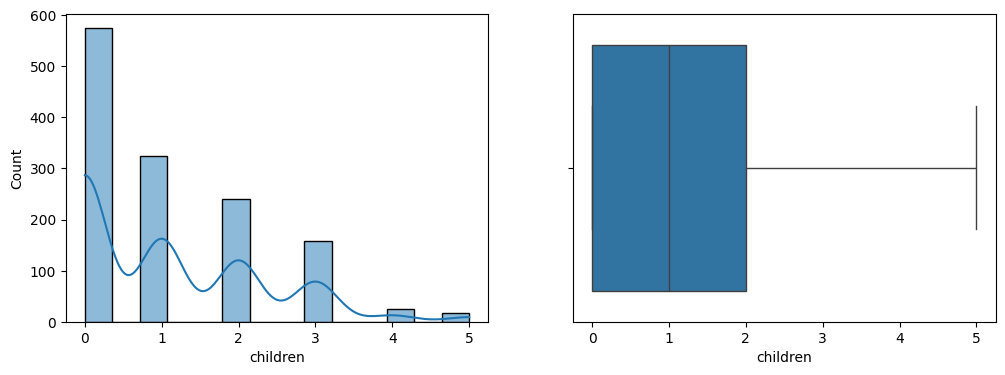

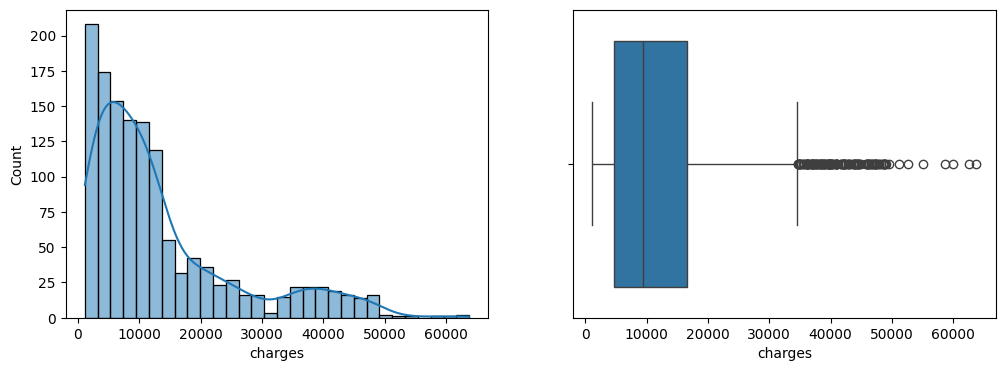

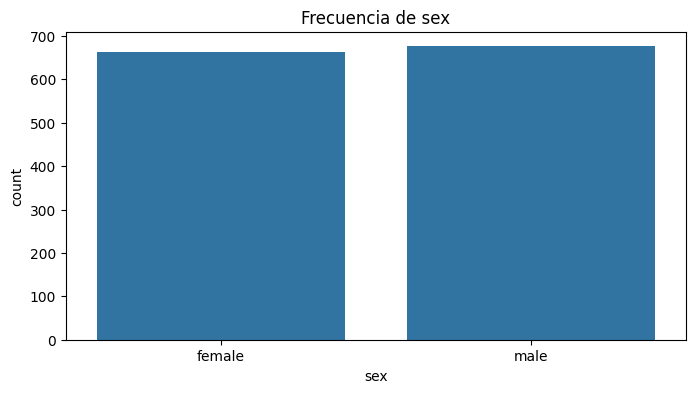

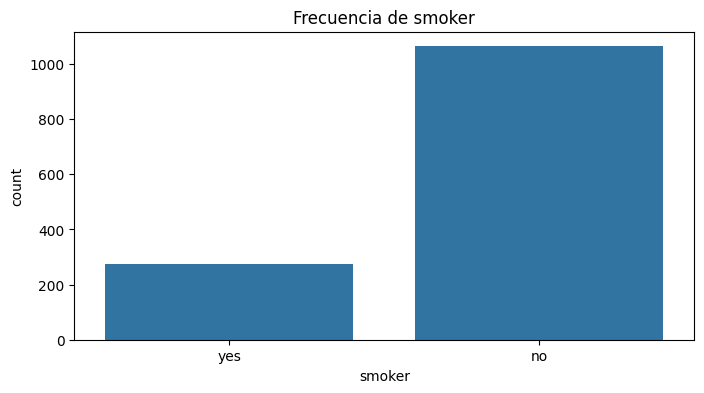

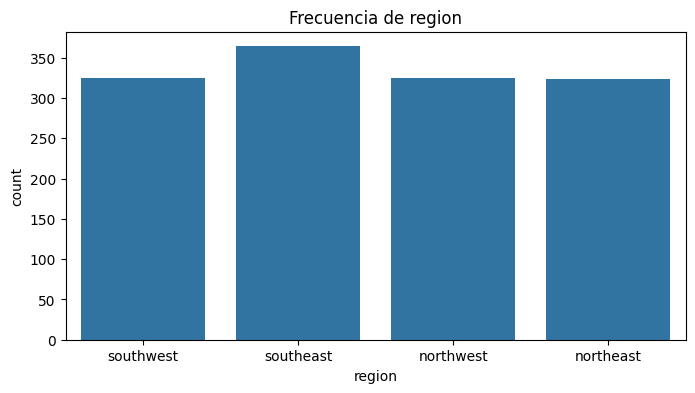

In [10]:
# Variables numéricas: Histrogramas y Boxplots
num_vars = ['age', 'bmi', 'children', 'charges']
for var in num_vars:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(insurance_df[var], kde=True, ax=axes[0])
    sns.boxplot(x=insurance_df[var], ax=axes[1])
    plt.show()

# Variables categóricas: Frecuencia
cat_vars = ['sex', 'smoker', 'region']
for var in cat_vars:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=insurance_df, x=var)
    plt.title(f'Frecuencia de {var}')
    plt.show()

Para responder los siguientes cuestionamientos, genera los gráficos indicados:

2a) ¿Hay diferencias significativas de las primas según el sexo? Compara la distribución de la variable `charges` por medio de un boxplot.

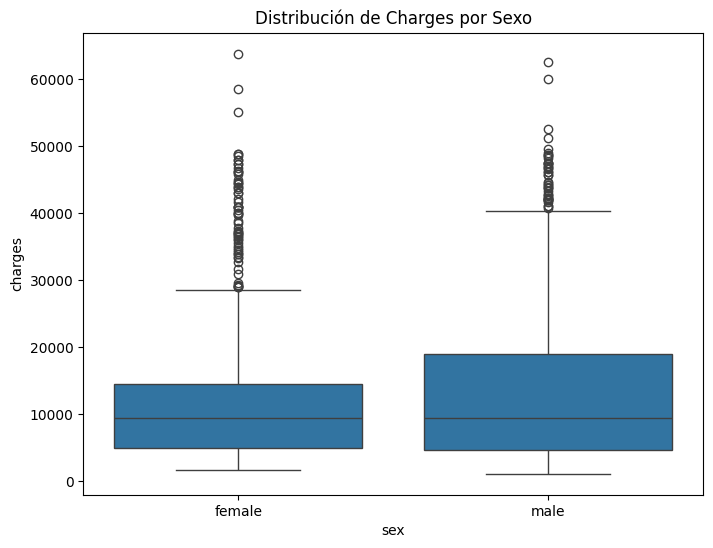

In [11]:
 plt.figure(figsize=(8, 6))
sns.boxplot(data=insurance_df, x='sex', y='charges')
plt.title('Distribución de Charges por Sexo')
plt.show()

Al comparar la distribución mediante el boxplot, se observa que no hay una diferencia significativa en la mediana de las primas entre ambos sexos. Sin embargo, el grupo de los hombres presenta una mayor dispersión en los cargos altos y valores atípicos más extremos que el grupo de las mujeres, lo que sugiere que los casos de costos médicos más elevados tienden a ser masculinos en este conjunto de datos

2b) Crea un diagrama de dispersión de `charges` versus el `bmi` que incorpore la distinción por las categorías `smoker` y `children` (tip: utiliza el parámetro `size`) ¿Hay alguna conclusión importante que se derive del gráfico?

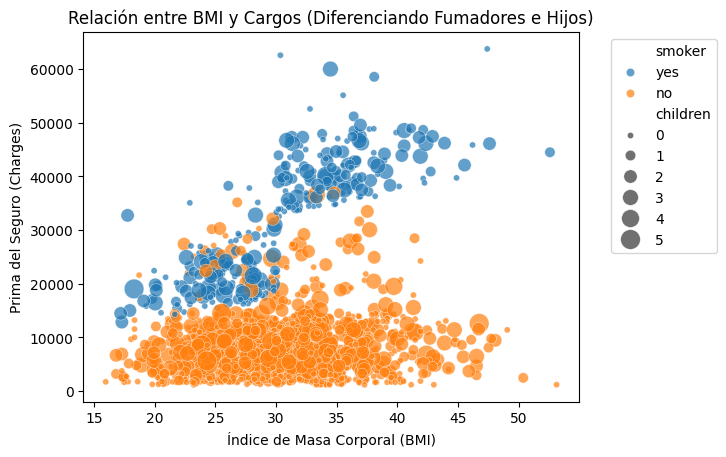

In [12]:
#hue para el color (fumadores) y size para el tamaño (hijos)
sns.scatterplot(data=insurance_df, x='bmi', y='charges', hue='smoker', size='children', sizes=(20, 200), alpha=0.7)

plt.title('Relación entre BMI y Cargos (Diferenciando Fumadores e Hijos)')
plt.xlabel('Índice de Masa Corporal (BMI)')
plt.ylabel('Prima del Seguro (Charges)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Se observa que el sexo no determina el costo promedio del seguro, pero el hábito de fumar es la variable más influyente. Existe una interacción crítica entre ser fumador y el BMI: los fumadores con obesidad (BMI > 30) representan el grupo con las primas más altas, superando los 40,000 USD, mientras que los no fumadores mantienen costos bajos independientemente de su peso.

2c) Elabora un mapa de calor que muestre la correlación de las variables numéricas.

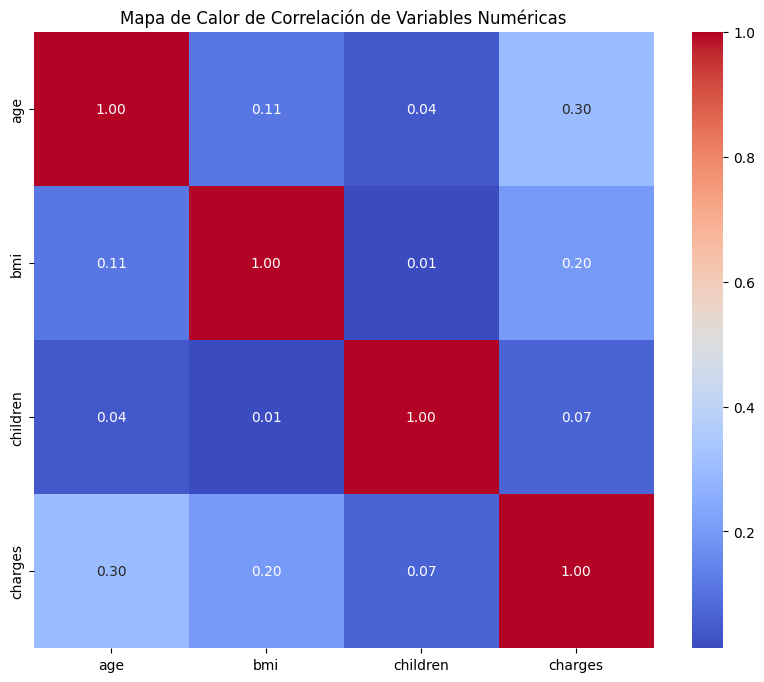

In [13]:
plt.figure(figsize=(10, 8))
# Usamos numeric_only=True para que solo tome las columnas con números
sns.heatmap(insurance_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor de Correlación de Variables Numéricas')
plt.show()

Obtén un dataframe con las observaciones que tengan valores atípicos en `charges`.

3a) ¿Cuál es el promedio de `age` y de `bmi` en el dataframe de valores atípicos obtenido?

In [14]:
#Calcular los cuartiles y el IQR de la columna charges
Q1 = insurance_df['charges'].quantile(0.25)
Q3 = insurance_df['charges'].quantile(0.75)
IQR = Q3 - Q1

#Definir el límite superior para detectar atípicos
# (Cualquier cargo mayor a este número es un outlier)
limite_superior = Q3 + 1.5 * IQR

#Crear el dataframe solo con los valores atípicos
outliers_df = insurance_df[insurance_df['charges'] > limite_superior]

#Obtener los promedios de edad y BMI de este grupo
promedio_age_outliers = outliers_df['age'].mean()
promedio_bmi_outliers = outliers_df['bmi'].mean()

print(f"Límite superior para ser outlier: ${limite_superior:,.2f}")
print(f"Cantidad de observaciones atípicas: {len(outliers_df)}")
print(f"Promedio de Edad en los outliers: {promedio_age_outliers:.2f} años")
print(f"Promedio de BMI en los outliers: {promedio_bmi_outliers:.2f}")

Límite superior para ser outlier: $34,489.35
Cantidad de observaciones atípicas: 139
Promedio de Edad en los outliers: 41.08 años
Promedio de BMI en los outliers: 35.56


3b) ¿Qué porcentaje de estas observaciones (en el dataframe de valores atípicos obtenidos) se corresponden a mujeres y a hombres? ¿A fumadores y no fumadores?

In [15]:
# Porcentaje por Sexo
print("\nDistribución por Sexo:")
print(outliers_df['sex'].value_counts(normalize=True) * 100)

# Porcentaje por Fumadores
print("\nDistribución de Fumadores:")
print(outliers_df['smoker'].value_counts(normalize=True) * 100)


Distribución por Sexo:
sex
male      64.028777
female    35.971223
Name: proportion, dtype: float64

Distribución de Fumadores:
smoker
yes    97.841727
no      2.158273
Name: proportion, dtype: float64


# **Parte 2**. Preprocesamiento

4. Separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`charges`).

In [16]:
# Separar predictores (X) y variable de respuesta (y)
X = insurance_df.drop('charges', axis=1) # Todas las columnas menos 'charges'
y = insurance_df['charges']             # Solo la columna 'charges'

# Verificar qué hay en cada una
print("Predictores (X):")
print(X.head())
print("\nVariable de salida (y):")
print(y.head())

Predictores (X):
   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest

Variable de salida (y):
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


5. Divide el conjunto en entrenamiento y prueba (80:20) considerando:


*   El parámetro `random_state` con el valor de 1 para garantizar reproducibilidad.
*   Analiza los diagramas de barras obtenidos en el ejercicio 1c. Con los resultados observados, es conveniente usar la variable `smoker` en la estrategia de estratificación.
*   Como ya tienes separadas en `X` e `y` los predictores y salida, consulta cómo ejecutar la función `train_test_split()` para obtener `Xtrain, Xtest, ytrain, ytest` en una única instrucción.

In [17]:
from sklearn.model_selection import train_test_split
# Dividir 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=1,
    stratify=X['smoker']
)

6. Prepara un transformador, denominado `preprocessing`, para aplicar escalamiento *MinMax* a los predictores numéricos y codificación *one-hot* a los categóricas.

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Definir qué columnas son de qué tipo

num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

# Crear el objeto 'preprocessing'
preprocessing = ColumnTransformer([
    # Nombre, Transformador, Columnas a las que se aplica
    ('num', MinMaxScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols)
])

# **Parte 3**. Entrenando y evaluando el modelo de RL

7. Ejecuta un pipeline con el transformador creado y el algoritmo de regresión lineal para entrenar un modelo denominado `lr_model`.

Evalúa el modelo en el conjunto de prueba y obtén la raíz del error cuadrático medio (`RMSE`) y la métrica `R` cuadrado ($R^2$). Aunque ésta última la estudiarás a detalle la próxima semana, ahora sólo debes saber que toma valores entre 0 y 1, donde 1 indica un ajuste perfecto y, por tanto, un modelo muy fiable para las previsiones futuras. La función de scikit-learn que determina esta métrica es: [`r2_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Crear el Pipeline que combina el preprocesamiento y el modelo
lr_model = Pipeline([
    ('pre', preprocessing),
    ('reg', LinearRegression())
])

# ENTRENAMIENTO: el modelo aprende la relación entre datos y costos
lr_model.fit(X_train, y_train)

# PREDICCIÓN: El modelo toma (X_test)
y_pred = lr_model.predict(X_test)

# EVALUACIÓN: Comparar las predicciones con la realidad (y_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Evaluación del Modelo lr_model ---")
print(f"RMSE (Error promedio): ${rmse:,.2f}")
print(f"R^2 (Precisión del ajuste): {r2:.4f}")

--- Evaluación del Modelo lr_model ---
RMSE (Error promedio): $5,698.76
R^2 (Precisión del ajuste): 0.7539


**Valora el rendimiento del modelo con los siguientes cambios:**


8. Reemplaza los outliers de `charges` con el límite superior (`Q3 + 1.5 * IQR`). Haz el cambio en ambos conjuntos: `ytrain` y `ytest`, previo a la aplicación del mismo pipeline. Guarda el modelo como `lr_model2`.


In [20]:
# Calcular el límite superior
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

#  Reemplazar los valores que superen el límite en y_train e y_test

y_train_clipped = y_train.clip(upper=limite_superior)
y_test_clipped = y_test.clip(upper=limite_superior)

#  Crear y entrenar el nuevo modelo lr_model2 con el mismo pipeline
from sklearn.base import clone
lr_model2 = clone(lr_model) # Clonamos la estructura del pipeline anterior

# Entrenamos con los nuevos datos "suavizados"
lr_model2.fit(X_train, y_train_clipped)

# 4. Evaluamos el nuevo modelo
y_pred2 = lr_model2.predict(X_test)
rmse2 = np.sqrt(mean_squared_error(y_test_clipped, y_pred2))
r2_2 = r2_score(y_test_clipped, y_pred2)

print(f"--- Evaluación del Modelo lr_model2 (Sin Outliers) ---")
print(f"Nuevo RMSE: ${rmse2:,.2f}")
print(f"Nuevo R^2: {r2_2:.4f}")

--- Evaluación del Modelo lr_model2 (Sin Outliers) ---
Nuevo RMSE: $4,995.03
Nuevo R^2: 0.7606


9. Prepara otro transformador, denominado `preprocessing2`, para aplicar escalamiento estándar a los predictores numéricos y codificación ordinal a los categóricas. Aplícalo en un nuevo pipeline utilizando nuevamente regresión lineal. Guarda el modelo como `lr_model3`.

**Nota.** Los cambios se ejecutan de manera consecutiva, por ejemplo: el reemplazo de los outliers también se ejecuta previo al transformador `preprocessing2` y así sucesivamente.

In [21]:
 from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Crear el nuevo transformador 'preprocessing2'
num_cols = ['age', 'bmi', 'children']
cat_cols = ['sex', 'smoker', 'region']

preprocessing2 = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OrdinalEncoder(), cat_cols)
])

# Crear el nuevo Pipeline
lr_model3 = Pipeline([
    ('pre', preprocessing2),
    ('reg', LinearRegression())
])

# Entrenamiento (Usando los datos con el tope en outliers)
lr_model3.fit(X_train, y_train_clipped)

# 4. Evaluación
y_pred3 = lr_model3.predict(X_test)
rmse3 = np.sqrt(mean_squared_error(y_test_clipped, y_pred3))
r2_3 = r2_score(y_test_clipped, y_pred3)

print(f"--- Evaluación del Modelo lr_model3 ---")
print(f"RMSE: ${rmse3:,.2f}")
print(f"R^2: {r2_3:.4f}")

--- Evaluación del Modelo lr_model3 ---
RMSE: $4,994.26
R^2: 0.7606


10. Utiliza regresión polinomial para verificar si se produce un mejor ajuste. Intenta con varios grados, aunque debes dejar en el código sólo el de mejor rendimiento. Guarda el modelo como `lr_model4`.

In [23]:
from sklearn.preprocessing import PolynomialFeatures

# Definir el grado que mejor rendimiento dio (Grado 2)
grado_optimo = 2

#  Crear el Pipeline que incluye la transformación polinomial
# El orden importa: 1. Limpiar (pre) -> 2. Crear curvas (poly) -> 3. Regresión (reg)
lr_model4 = Pipeline([
    ('pre', preprocessing2),
    ('poly', PolynomialFeatures(degree=grado_optimo)),
    ('reg', LinearRegression())
])

# Entrenamiento (con los datos sin outliers extremos)
lr_model4.fit(X_train, y_train_clipped)

# Evaluación
y_pred4 = lr_model4.predict(X_test)
rmse4 = np.sqrt(mean_squared_error(y_test_clipped, y_pred4))
r2_4 = r2_score(y_test_clipped, y_pred4)

print(f"--- Evaluación del Modelo lr_model4 (Polinomial Grado {grado_optimo}) ---")
print(f"RMSE: ${rmse4:,.2f}")
print(f"R^2: {r2_4:.4f}")

--- Evaluación del Modelo lr_model4 (Polinomial Grado 2) ---
RMSE: $4,384.47
R^2: 0.8155
